<a href="https://colab.research.google.com/github/financieras/articulos/blob/main/linear_regression_english.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fundamentals of Linear Regression
## Gradient Descent vs Scikit-learn in a Practical Case

# 1. Introduction

## 1.1 What is Linear Regression?

Linear regression is one of the fundamental algorithms in Machine Learning. Its goal is to find the **best straight line** that describes the relationship between two variables.

Mathematically, we seek a function:

$$y = w_0 + w_1 \cdot x$$

Where:
- **$y$**: variable we want to predict (price)
- **$x$**: known variable (square meters)
- **$w_0$**: intercept or $bias$ (price when x=0)
- **$w_1$**: slope (how much the price increases on average for each additional m²)

## 1.2 Practical application: Predicting housing prices

Imagine you're a real estate agent and need to quickly estimate the price of a home knowing only its square meters. Linear regression allows you to:

✓ Make predictions based on historical data  
✓ Understand the relationship between size and price  
✓ Detect overvalued or undervalued properties

---

# 2. The Dataset

## 2.1 Description of the housing price data

We'll work with a set of 10 second-hand homes, where we know:
- **Area**: square meters of the property
- **Price**: sale price in thousands of dollars

## 2.2 Loading, basic exploration and visualization

Number of houses: 10
Area range: 50m² - 100m²
Price range: $140k - $300k
Average price per m²: $2.94k


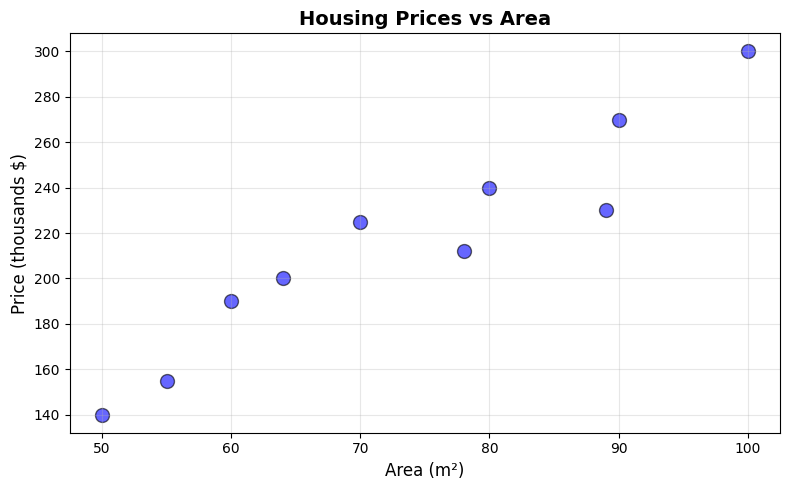

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Data: housing area (m²) vs price (thousands $)
area = np.array([50, 55, 60, 64, 70, 78, 80, 89, 90, 100])
price = np.array([140, 155, 190, 200, 225, 212, 240, 230, 270, 300])

# Basic exploration
print(f"Number of houses: {len(area)}")
print(f"Area range: {area.min()}m² - {area.max()}m²")
print(f"Price range: ${price.min()}k - ${price.max()}k")
print(f"Average price per m²: ${(price/area).mean():.2f}k")

# Visualization
plt.figure(figsize=(8, 5))
plt.scatter(area, price, color='blue', s=100, alpha=0.6, edgecolors='black')
plt.xlabel('Area (m²)', fontsize=12)
plt.ylabel('Price (thousands $)', fontsize=12)
plt.title('Housing Prices vs Area', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observation**: A positive trend can be seen: the larger the area, the higher the price.

## 2.3 Visualization of errors (residuals)

In the following graph, the vertical green lines show the difference between actual and predicted prices. We seek the line that makes these squared differences as small as possible.

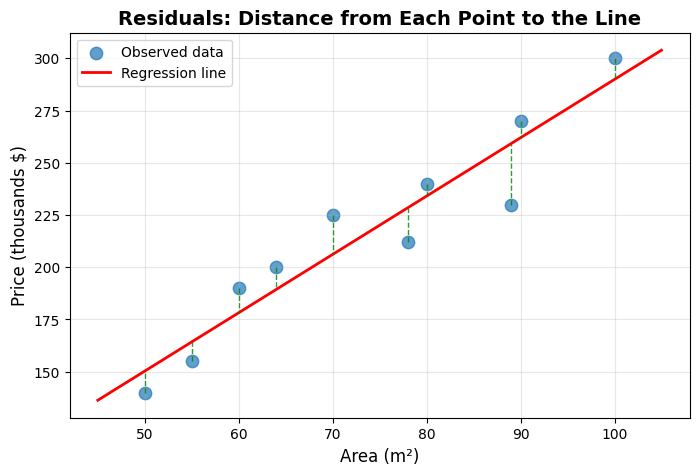

In [2]:
# @title Residuals
# Calculate regression line using the direct formula
X_matrix = np.column_stack([np.ones(len(area)), area])  # add column of 1s
w = np.linalg.inv(X_matrix.T @ X_matrix) @ X_matrix.T @ price

# Visualization with error lines
plt.figure(figsize=(8, 5))
plt.scatter(area, price, alpha=0.7, s=80, label='Observed data')

# Regression line
area_range = np.linspace(45, 105, 100)
price_range = w[0] + w[1] * area_range
plt.plot(area_range, price_range, 'r-', linewidth=2, label='Regression line')

# Vertical lines showing the errors
for xi, yi in zip(area, price):
    yi_pred = w[0] + w[1] * xi
    plt.plot([xi, xi], [yi, yi_pred], 'g--', alpha=0.8, linewidth=1)

plt.xlabel('Area (m²)', fontsize=12)
plt.ylabel('Price (thousands $)', fontsize=12)
plt.title('Residuals: Distance from Each Point to the Line', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 2.4 Why normalize? The importance of scaling

When using Gradient Descent, variables with different scales can cause problems:

- **Without normalization**: Area (50-100) vs Price (140-300)
- The algorithm converges **slowly** or **unstably**
- The number of steps the algorithm must take is excessive

**Solution: Z-score normalization**

$$z = \frac{x - \mu}{\sigma}$$

Transforms the data so they have mean zero ($\mu=0$) and standard deviation one ($\sigma=1$).


In [3]:
def normalize(data):
    mean = data.mean()
    std = data.std()
    return (data - mean) / std, mean, std

# Normalize our data
area_norm, area_mean, area_std = normalize(area)
price_norm, price_mean, price_std = normalize(price)

print(f"Original area: \t\t{area[0]}, {area[-1]}")
print(f"Normalized area: \t{area_norm[0]:.2f}, {area_norm[-1]:.2f}")
print(f"\nNormalized area:\n\tMean: {area_norm.mean():.2e} \n\tStd: {area_norm.std():.2f}")

Original area: 		50, 100
Normalized area: 	-1.51, 1.68

Normalized area:
	Mean: 3.11e-16 
	Std: 1.00


---

# 3. Cost Function (Mean Squared Error)

## 3.1 What is a cost function?

The **cost function** measures how far our predictions are from the actual values. In linear regression, we use **Mean Squared Error (MSE)**:

$$J(w_0, w_1) = \frac{1}{2n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Where:
- **$y_i$**: actual price
- **$\hat{y}_i = w_0 + w_1 \cdot x_i$**: predicted price
- **$n$**: number of examples

**Why square the errors?**
1. Penalizes large errors more (an error of 20 is worse than two errors of 10)
2. Eliminates negative values (error of -5 and +5 don't cancel each other out)
3. Creates a smooth, differentiable function (essential for Gradient Descent)

## 3.2 Implementation in Python

In [ ]:
def cost_function(area, price, w_0, w_1):
    """
    Calculates Mean Squared Error (MSE)
    """
    n = len(area)
    predictions = w_0 + w_1 * area
    errors = price - predictions
    cost = (1/(2*n)) * np.sum(errors**2)
    return cost

## 3.3 Example: Calculating cost with arbitrary parameters

In [ ]:
# Test with arbitrary parameters
w_0_test = 50   # Arbitrary intercept
w_1_test = 2    # Arbitrary slope

cost = cost_function(area_norm, price_norm, w_0_test, w_1_test)
print(f"Cost with w₀={w_0_test}, w₁={w_1_test}: {cost:.4f}")

# Visualization
plt.figure(figsize=(8, 5))
plt.scatter(area_norm, price_norm, color='blue', s=100, alpha=0.6,
            edgecolors='black', label='Normalized data')

# Test line
area_line = np.linspace(area_norm.min()-0.5, area_norm.max()+0.5, 100)
price_line = w_0_test + w_1_test * area_line
plt.plot(area_line, price_line, 'r-', linewidth=2,
         label=f'Test line: y={w_0_test}+{w_1_test}x')

plt.xlabel('Normalized Area', fontsize=12)
plt.ylabel('Normalized Price', fontsize=12)
plt.title('Test Line with Arbitrary Parameters', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.show()

**Observation**: With arbitrary parameters, the cost is high. Our goal is to find the values of $w_0$ and $w_1$ that **minimize** this cost.

---

# 4. Gradient Descent: The Optimization Algorithm

## 4.1 Intuition: Descending a mountain

Imagine you're on a mountain in the fog and want to reach the valley (minimum cost):

1. **Look around**: Calculate the slope at your current position
2. **Take a step downward**: Move in the direction that descends most steeply
3. **Repeat**: Keep descending until you can't go any lower

Gradient Descent does exactly this with our parameters $w_0$ and $w_1$.

## 4.2 Mathematical formulation

The **gradient** indicates the direction of maximum growth. We move in the **opposite direction** to descend:

$$w_0 := w_0 - \alpha \frac{\partial J}{\partial w_0}$$

$$w_1 := w_1 - \alpha \frac{\partial J}{\partial w_1}$$

Where:
- **$\alpha$**: learning rate (step size)
- **$\frac{\partial J}{\partial w_i}$**: partial derivative (slope direction)

**Partial derivatives**:

$$\frac{\partial J}{\partial w_0} = -\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)$$

$$\frac{\partial J}{\partial w_1} = -\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i) \cdot x_i$$

## 4.3 Implementation in Python

In [ ]:
def gradient_descent(area, price, w_0, w_1, alpha, iterations):
    """
    Optimizes w_0 and w_1 using Gradient Descent

    Parameters:
    - area, price: normalized training data
    - w_0, w_1: initial parameters
    - alpha: learning rate
    - iterations: number of iterations

    Returns:
    - w_0, w_1: optimized parameters
    - cost_history: cost evolution
    """
    n = len(area)
    cost_history = []

    for i in range(iterations):
        # Predictions
        predictions = w_0 + w_1 * area

        # Errors
        errors = price - predictions

        # Gradients (partial derivatives)
        dw_0 = -(1/n) * np.sum(errors)
        dw_1 = -(1/n) * np.sum(errors * area)

        # Update parameters
        w_0 = w_0 - alpha * dw_0
        w_1 = w_1 - alpha * dw_1

        # Save cost
        cost = cost_function(area, price, w_0, w_1)
        cost_history.append(cost)

        # Show progress every 100 iterations
        if i % 100 == 0:
            print(f"Iteration {i}: Cost = {cost:.4f}, w₀ = {w_0:.4f}, w₁ = {w_1:.4f}")

    return w_0, w_1, cost_history

---

# 5. Training the Model with Gradient Descent

## 5.1 Hyperparameters and execution

In [ ]:
# Initial hyperparameters
w_0_init = 0.0      # Initial intercept
w_1_init = 0.0      # Initial slope
alpha = 0.01        # Learning rate
iterations = 1000   # Number of iterations

# Train the model
w_0_final, w_1_final, cost_history = gradient_descent(
    area_norm, price_norm, w_0_init, w_1_init, alpha, iterations
)

print(f"\nOptimized parameters (normalized):")
print(f"w₀ = {w_0_final:.4f}")
print(f"w₁ = {w_1_final:.4f}")
print(f"Final cost: {cost_history[-1]:.4f}")

## 5.2 Cost evolution

In [ ]:
# Visualize convergence
plt.figure(figsize=(10, 5))
plt.plot(cost_history, linewidth=2, color='purple')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Cost J(w₀, w₁)', fontsize=12)
plt.title('Cost Evolution during Training', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observation**: The cost decreases rapidly in the first iterations and then stabilizes. This indicates that the algorithm has **converged** to the optimal solution.

## 5.3 Visualization of the final model

In [ ]:
# Predictions with the trained model
predictions_norm = w_0_final + w_1_final * area_norm

# Visualization
plt.figure(figsize=(8, 5))
plt.scatter(area_norm, price_norm, color='blue', s=100, alpha=0.6,
            edgecolors='black', label='Training data')
plt.plot(area_norm, predictions_norm, 'r-', linewidth=2,
         label=f'Trained model: y={w_0_final:.2f}+{w_1_final:.2f}x')
plt.xlabel('Normalized Area', fontsize=12)
plt.ylabel('Normalized Price', fontsize=12)
plt.title('Linear Regression Model (Normalized)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.show()

---

# 6. Denormalization: Return to Original Scale

## 6.1 Why denormalize?

We trained the model with **normalized data** (mean=0, std=1), but we need to make predictions in the **original scale** (square meters and thousands of dollars).

**Transformation formulas**:

From normalized parameters $(w_0^{norm}, w_1^{norm})$ to original parameters $(w_0, w_1)$:

$$w_1 = w_1^{norm} \cdot \frac{\sigma_y}{\sigma_x}$$

$$w_0 = \mu_y - w_1 \cdot \mu_x$$

Where:
- $\mu_x, \sigma_x$: mean and standard deviation of area
- $\mu_y, \sigma_y$: mean and standard deviation of price

## 6.2 Implementation

In [ ]:
def denormalize_parameters(w_0_norm, w_1_norm, mean_x, std_x, mean_y, std_y):
    """
    Converts normalized parameters to original scale
    """
    w_1_original = w_1_norm * (std_y / std_x)
    w_0_original = mean_y - w_1_original * mean_x
    return w_0_original, w_1_original

# Denormalize
w_0_original, w_1_original = denormalize_parameters(
    w_0_final, w_1_final,
    area_mean, area_std,
    price_mean, price_std
)

print("Parameters in original scale:")
print(f"w₀ (intercept) = {w_0_original:.2f} (thousands $)")
print(f"w₁ (slope) = {w_1_original:.2f} (thousands $ per m²)")

## 6.3 Interpretation of results

**Practical interpretation**:

$$\text{Price} = w_0 + w_1 \cdot \text{Area}$$

Example with our values:
- **$w_0 \approx 10.72$**: Base price of a 0m² house (not realistic, but mathematically necessary)
- **$w_1 \approx 2.79$**: For each additional square meter, the price increases by $2,790

**Real example**:
- House of 75m²: $\text{Price} = 10.72 + 2.79 \times 75 = 220.11$ thousand dollars

## 6.4 Predictions and visualization

In [ ]:
# Predictions in original scale
predictions = w_0_original + w_1_original * area

# Visualization
plt.figure(figsize=(8, 5))
plt.scatter(area, price, color='blue', s=100, alpha=0.6,
            edgecolors='black', label='Real data')
plt.plot(area, predictions, 'r-', linewidth=2,
         label=f'Model: y={w_0_original:.2f}+{w_1_original:.2f}x')
plt.xlabel('Area (m²)', fontsize=12)
plt.ylabel('Price (thousands $)', fontsize=12)
plt.title('Final Model (Original Scale)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Example predictions
test_areas = [65, 75, 85]
for test_area in test_areas:
    predicted_price = w_0_original + w_1_original * test_area
    print(f"House of {test_area}m² → ${predicted_price:.2f}k")

---

# 7. Scikit-learn: The Professional Solution

## 7.1 Why use Scikit-learn?

While implementing Gradient Descent manually is **excellent for learning**, in real projects we use **Scikit-learn**:

✓ Optimized and tested code  
✓ Automatically handles normalization  
✓ Direct analytical solution (no iterations)  
✓ Easy integration with other ML tools  

**Normal Equation (Scikit-learn uses this)**:

$$w = (X^T X)^{-1} X^T y$$

Calculates optimal parameters **directly** without iterations.


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Create model
model = LinearRegression()

# Prepare data (Scikit-learn expects matrices)
X_train = area.reshape(-1, 1)  # Convert to column matrix
y_train = price

# Fit the model
model.fit(X_train, y_train)     # The 'fit' method works wonders

# Get parameters
w_0_sklearn = model.intercept_
w_1_sklearn = model.coef_[0]

print("Scikit-learn parameters:")
print(f"w₀ (intercept) = {w_0_sklearn:.2f} (thousands $)")
print(f"w₁ (slope) = {w_1_sklearn:.2f} (thousands $ per m²)")

## 7.2 Training and predictions

Once the model is trained, we can evaluate its performance and make predictions with unseen data.

In [ ]:
# Make predictions
predictions_sklearn = model.predict(X_train)

# Calculate metrics
mse_sklearn = mean_squared_error(y_train, predictions_sklearn)
rmse_sklearn = np.sqrt(mse_sklearn)
r2_sklearn = r2_score(y_train, predictions_sklearn)

print(f"\nMetrics:")
print(f"MSE = {mse_sklearn:.2f}")
print(f"RMSE = {rmse_sklearn:.2f} (thousands $)")
print(f"R² = {r2_sklearn:.4f}")

# Example prediction
example_prediction_sklearn = model.predict([[75]])[0]
print(f"\nExample prediction:")
print(f"House of 75m² → ${example_prediction_sklearn:.2f}k")

---

# 8. Comparison and Evaluation

## 8.1 Side-by-side results

In [ ]:
# @title Compare parameters
import pandas as pd
comparison_df = {
    'Method': ['Manual (Gradient Descent)', 'Scikit-learn'],
    'w₀ (intercept)': [w_0_original, w_0_sklearn],
    'w₁ (slope)': [w_1_original, w_1_sklearn]
}

df = pd.DataFrame(comparison_df)
print(df.to_string(index=False))

# Calculate metrics for manual implementation
mse_manual = mean_squared_error(price, predictions)
rmse_manual = np.sqrt(mse_manual)
r2_manual = r2_score(price, predictions)

print(f"\nMetrics comparison:")
print(f"{'Method':<30} {'MSE':<10} {'RMSE':<10} {'R²':<10}")
print(f"{'='*60}")
print(f"{'Manual (Gradient Descent)':<30} {mse_manual:<10.2f} {rmse_manual:<10.2f} {r2_manual:<10.4f}")
print(f"{'Scikit-learn':<30} {mse_sklearn:<10.2f} {rmse_sklearn:<10.2f} {r2_sklearn:<10.4f}")

# Visual comparison
plt.figure(figsize=(8, 5))
plt.scatter(area, price, color='blue', s=100, alpha=0.6,
            edgecolors='black', label='Real data', zorder=3)
plt.plot(area, predictions, color='red', linewidth=3,
         label=f'Manual: y={w_0_original:.2f}+{w_1_original:.2f}x',
         linestyle='-', alpha=0.8)
plt.plot(area, predictions_sklearn, color='limegreen', linewidth=2.5,
         label=f'Sklearn: y={w_0_sklearn:.2f}+{w_1_sklearn:.2f}x',
         linestyle='--', alpha=0.7)
plt.xlabel('Area (m²)', fontsize=12)
plt.ylabel('Price (thousands $)', fontsize=12)
plt.title('Comparison: Manual vs Scikit-learn', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8.2 Metrics: R² and interpretations

**Coefficient of Determination (R²)**:

$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

**Interpretation**:
- **R² \approx 1**: Perfect fit (exact predictions)
- **R² \approx 0.9**: Excellent fit (our case: explains 90% of price variations)
- **R² \approx 0.7-0.8**: Good fit for practical applications
- **R² < 0.5**: Weak fit (consider more variables or models)

R² is interpreted directly as a percentage: **R² = 0.90 means that 90% of the differences in prices are explained by area**. The remaining 10% depends on factors not considered (location, condition, etc.).

**Observation**: Both methods converge to practically identical results. The small differences are due to:
- Gradient Descent: iterative approximation
- Scikit-learn: exact analytical solution

---

# 9. Conclusion

## 9.1 Correlation is not causation

Although we found a strong relationship between area and price, we must be cautious:

- **Correlation**: There is a statistical relationship (high R²)
- **Causation**: We cannot affirm that area *causes* the price

**Omitted factors** that also influence:
- Property location
- State of conservation
- Year of construction
- Nearby services

**Example of spurious correlation**: Ice cream consumption correlates with pool drownings, but ice cream doesn't *cause* drownings. Both increase in summer.

> More examples: [tylervigen.com/spurious-correlations](https://www.tylervigen.com/spurious-correlations)

## 9.2 Practical summary

1. **For learning**: Implement Gradient Descent manually (you'll better understand how it works)
2. **For real projects**: Use Scikit-learn (it's faster and more robust)
3. **For large datasets**: Consider Mini-Batch Gradient Descent
4. **Always**: Visualize your data, evaluate metrics (R², RMSE) and question your results

## 9.3 Reflection

- In this world of AI and deep neural networks, linear regression continues to be a fundamental Machine Learning tool. It's still extensively used for its magnificent results and, especially, for the explainability of the model it generates.
- When others talk about "black boxes" in complex models, you'll be able to explain exactly how your regression model makes decisions: "For each additional square meter, the price increases by X dollars". That clarity has immense value in real applications.

---